In [1]:
import os, glob, cv2, time
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import warnings
from scipy.ndimage import gaussian_filter1d
import scipy.io as sio


warnings.filterwarnings("ignore")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATA_ROOT = "Avenue_Dataset/"


In [2]:
def set_seed(seed=42):
    import random, numpy as np, torch
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


In [3]:
set_seed() 

In [4]:
class AvenueTrainClips(Dataset):
    def __init__(self, root, seq_len=16, size=(128,128)):
        self.seq_len = seq_len
        self.transform = transforms.Compose([
            transforms.Resize(size),
            transforms.ToTensor()
        ])

        self.clips = []
        video_root = os.path.join(root, "training_videos")
        videos = sorted(glob.glob(os.path.join(video_root, "*.avi")))

        for v in videos:
            cap = cv2.VideoCapture(v)
            frames = []

            while True:
                ret, frame = cap.read()
                if not ret:
                    break
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
                frames.append(frame)

            cap.release()

            for i in range(len(frames) - seq_len + 1):
                self.clips.append(frames[i:i+seq_len])

    def __len__(self):
        return len(self.clips)

    def __getitem__(self, idx):
        clip = self.clips[idx]
        seq = []

        for f in clip:
            img = Image.fromarray(f)
            img = self.transform(img)
            seq.append(img)

        seq = torch.stack(seq, dim=1)  
        return seq

class AvenueTestVideos(Dataset):
    def __init__(self, root, size=(128,128)):
        self.transform = transforms.Compose([
            transforms.Resize(size),
            transforms.ToTensor()
        ])

        video_root = os.path.join(root, "testing_videos")
        self.videos = []

        videos = sorted(glob.glob(os.path.join(video_root, "*.avi")))
        for v in videos:
            name = os.path.splitext(os.path.basename(v))[0]

            cap = cv2.VideoCapture(v)
            frames = []

            while True:
                ret, frame = cap.read()
                if not ret:
                    break
                frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
                frames.append(frame)

            cap.release()
            self.videos.append((name, frames))

    def __len__(self):
        return len(self.videos)

    def __getitem__(self, idx):
        name, frames = self.videos[idx]
        seq = []

        for f in frames:
            img = Image.fromarray(f)
            img = self.transform(img)
            seq.append(img)

        seq = torch.stack(seq, dim=0)  
        return name, seq, frames

In [5]:
import math

class MemoryUnit(nn.Module):
    def __init__(self, mem_dim, fea_dim, shrink_thres=0.0025):
        super().__init__()
        self.mem_dim = mem_dim
        self.weight = nn.Parameter(torch.Tensor(mem_dim, fea_dim))
        self.shrink_thres = shrink_thres
        self.reset_parameters()

    def reset_parameters(self):
        stdv = 1. / math.sqrt(self.weight.size(1))
        self.weight.data.uniform_(-stdv, stdv)

    def forward(self, x):
        att = F.softmax(F.linear(x, self.weight), dim=1)

        if self.shrink_thres > 0:
            att = (F.relu(att - self.shrink_thres) * att) / (torch.abs(att - self.shrink_thres) + 1e-12)
            att = F.normalize(att, p=1, dim=1)

        out = F.linear(att, self.weight.t())
        return out, att


class MemModule(nn.Module):
    def __init__(self, mem_dim, fea_dim, shrink_thres=0.0025):
        super().__init__()
        self.mem_dim = mem_dim
        self.mem = MemoryUnit(mem_dim, fea_dim, shrink_thres)

    def forward(self, x):
        s = x.shape
        z = x.permute(0,2,3,4,1).contiguous().view(-1, s[1])

        out, att = self.mem(z)

        out = out.view(s[0], s[2], s[3], s[4], s[1]).permute(0,4,1,2,3)
        att = att.view(s[0], s[2], s[3], s[4], self.mem_dim).permute(0,4,1,2,3)

        return {"output": out, "att": att}


In [6]:
class DualMemAE3D(nn.Module):
    def __init__(self, ch=1, mem_s=400, mem_t=200, shrink=0.0025):
        super().__init__()

        f, f2, f4 = 128, 96, 256

        self.encoder = nn.Sequential(
            nn.Conv3d(ch,f2,3,(1,2,2),1),
            nn.BatchNorm3d(f2),
            nn.LeakyReLU(0.2,True),

            nn.Conv3d(f2,f,3,2,1),
            nn.BatchNorm3d(f),
            nn.LeakyReLU(0.2,True),

            nn.Conv3d(f,f4,3,2,1),
            nn.BatchNorm3d(f4),
            nn.LeakyReLU(0.2,True),

            nn.Conv3d(f4,f4,3,2,1),
            nn.BatchNorm3d(f4),
            nn.LeakyReLU(0.2,True),
        )

        self.mem_s = MemModule(mem_s, f4, shrink)
        self.mem_t = MemModule(mem_t, f4, shrink)

        self.decoder = nn.Sequential(
            nn.ConvTranspose3d(f4,f4,3,2,1,1),
            nn.BatchNorm3d(f4),
            nn.LeakyReLU(0.2,True),

            nn.ConvTranspose3d(f4,f,3,2,1,1),
            nn.BatchNorm3d(f),
            nn.LeakyReLU(0.2,True),

            nn.ConvTranspose3d(f,f2,3,2,1,1),
            nn.BatchNorm3d(f2),
            nn.LeakyReLU(0.2,True),

            nn.ConvTranspose3d(f2,ch,3,(1,2,2),1,(0,1,1))
        )

        self.fusion = nn.Sequential(
            nn.Conv3d(f4 * 2, f4, kernel_size=1),
            nn.BatchNorm3d(f4),
            nn.LeakyReLU(0.2, True)
        )

        self.pred_head = nn.Sequential(
            nn.Conv3d(f4, f4, 1),
            nn.LeakyReLU(0.2, True),
            nn.Conv3d(f4, f4, 1)
        )

    def forward(self, x):
        z = self.encoder(x)

        s = self.mem_s(z)

        z_t = F.adaptive_avg_pool3d(z, (z.size(2), 2, 2))
        
        t = self.mem_t(z_t)

        t_out = F.interpolate(
            t["output"],
            size=s["output"].shape[2:],
            mode="trilinear",
            align_corners=False
        )

        fused = torch.cat([s["output"], t_out], dim=1)
        z_fused = self.fusion(fused)

        recon = self.decoder(z_fused)

        return {
            "recon": recon,
            "z": z,
            "s": s,
            "t": t
        }

    def recon_loss(self, x, recon, ratio=0.1):
        err = (recon - x).pow(2).mean(dim=1)
        k = int(ratio * err[0].numel())
        topk = torch.topk(
            err.view(err.size(0), -1),
            k=k,
            dim=1
        )[0]
        return topk.mean()

    def pred_loss(self, z_pred, z_target):
        if z_pred is None:
            return torch.tensor(0.0, device=z_target.device)
        return F.mse_loss(z_pred, z_target)

    def entropy_loss(self, att, eps=1e-8):
        p = att + eps
        return -(p * torch.log(p)).sum(dim=1).mean()

    def usage_loss(self, usage):
        uniform = torch.full_like(usage, 1.0 / usage.numel())
        return F.mse_loss(usage, uniform)

    def separation_loss(self, mem_weight):
        mem_norm = F.normalize(mem_weight, dim=1)
        sim = torch.matmul(mem_norm, mem_norm.t())
        I = torch.eye(sim.size(0), device=sim.device)
        return ((sim - I) ** 2).mean()


    def compute_loss(self, x, outputs, epoch,
                 warmup=20,
                 lambda_ent=0.0015,
                 lambda_usage=0.005,
                 lambda_sep=0.0005):
        recon = F.mse_loss(outputs["recon"], x)

        s, t = outputs["s"], outputs["t"]

        loss_ent = (
            self.entropy_loss(s["att"]) +
            0.5 * self.entropy_loss(t["att"])
        )

        usage_s = s["att"].mean(dim=[0,2,3,4])
        usage_s = usage_s / (usage_s.sum() + 1e-6)

        usage_t = t["att"].mean(dim=[0,2,3,4])
        usage_t = usage_t / (usage_t.sum() + 1e-6)

        loss_usage = self.usage_loss(usage_s) + 0.5 * self.usage_loss(usage_t)

        loss_sep = (
            self.separation_loss(self.mem_s.mem.weight) +
            0.5 * self.separation_loss(self.mem_t.mem.weight)
        )

        w = min(1.0, epoch / warmup)
        sep_w = lambda_sep if epoch >= 40 else 0.0

        loss = (
            recon
            + w * lambda_ent * loss_ent
            + w * lambda_usage * loss_usage
            + sep_w * loss_sep
        )

        return {
            "total": loss,
            "recon": recon,
            "ent": loss_ent,
            "usage": loss_usage,
            "sep": loss_sep
        }


In [7]:
train_data = AvenueTrainClips(DATA_ROOT)
loader = DataLoader(train_data, batch_size=8, shuffle=True)
SHRINK = 0.0025


model = DualMemAE3D(shrink=SHRINK).to(DEVICE)
opt = torch.optim.Adam(
    model.parameters(),
    lr=1e-4,
    betas=(0.9, 0.999),
    weight_decay=5e-6
)

# lambda_mem = 0.3
lambda_ent = 0.001
lambda_usage = 0.001
lambda_sep = 0.0003
loss_usage_weight = 0.005

In [23]:
for epoch in range(120):
    model.train()
    total = 0

    for x in tqdm(loader):
        x = x.to(DEVICE)
        opt.zero_grad()

        out = model(x)

        losses = model.compute_loss(
            x, out, epoch,
            warmup=30,
            lambda_ent=lambda_ent,
            lambda_usage=lambda_usage,
            lambda_sep=lambda_sep
        )


        loss = losses["total"]
        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(), 5.0
        )

        opt.step()
        total += loss.item()

    print(f"Epoch {epoch+1} | loss {total/len(loader):.6f}")

    if (epoch + 1) % 5 == 0:
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict()
            },
            f"./DualMemAE_Avenue/ckpt_{epoch+1}.pt"
        )


100%|██████████| 1886/1886 [10:40<00:00,  2.94it/s]


Epoch 1 | loss 0.019652


100%|██████████| 1886/1886 [12:56<00:00,  2.43it/s]


Epoch 2 | loss 0.001746


100%|██████████| 1886/1886 [15:04<00:00,  2.08it/s]


...

Epoch 118 | loss 0.000780


100%|██████████| 1886/1886 [07:59<00:00,  3.93it/s]


Epoch 119 | loss 0.000790


100%|██████████| 1886/1886 [07:59<00:00,  3.93it/s]

Epoch 120 | loss 0.000786


In [8]:
def load_avenue_gt(video_idx, gt_root):
    mat_path = os.path.join(gt_root, f"{int(video_idx)}_label.mat")
    mat = sio.loadmat(mat_path)

    volLabel = mat["volLabel"][0]

    gt = []
    for frame_mask in volLabel:
        if np.sum(frame_mask) > 0:
            gt.append(1)
        else:
            gt.append(0)

    return np.array(gt, dtype=np.int32)


In [9]:
def att_entropy(att):
    p = att / (att.sum(dim=1, keepdim=True) + 1e-6)
    ent = - (p * torch.log(p + 1e-6)).sum(dim=1)
    return ent.mean().item()


In [10]:
def temporal_smooth(x, sigma=5):
    return gaussian_filter1d(x, sigma=sigma)

In [11]:
def temporal_score(x, win=7):
    out = x.copy()
    for i in range(len(x)):
        l = max(0, i - win)
        r = min(len(x), i + win)
        out[i] = np.max(x[l:r])
    return out

In [12]:
def att_entropy(att, eps=1e-8):
    p = att + eps
    ent = -(p * torch.log(p)).sum(dim=1)
    return ent.mean(dim=[1,2,3])   # [B]


In [ ]:
def evaluate(ckpt_path, verbose=1):
    model = DualMemAE3D(shrink=SHRINK).to(DEVICE)
    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    test_root = os.path.join(DATA_ROOT, "testing_label_mask")
    test_set = AvenueTestVideos(DATA_ROOT)

    all_scores = []
    all_labels = []
    total_time = []

    with torch.no_grad():
        for name, vid, _ in tqdm(test_set):

            vid = vid.to(DEVICE)
            video_scores = []

            for i in range(len(vid) - 15):
                clip = vid[i:i+16].unsqueeze(0).permute(0,2,1,3,4)

                torch.cuda.synchronize()
                t0 = time.time()

                out = model(clip)

                torch.cuda.synchronize()
                total_time.append(time.time() - t0)

                recon = out["recon"]
                s = out["s"]
                t = out["t"]

                err = F.mse_loss(recon, clip).item()

                ent_s = att_entropy(s["att"]).item()
                ent_t = att_entropy(t["att"]).item()

                score = err * (1 + 2.0 * ent_s) + 0.3 * ent_t

                video_scores.append(score)

            if len(video_scores) == 0:
                continue

            video_scores = np.array(video_scores, dtype=np.float32)

            video_scores_1 = temporal_score(video_scores, win=3)
            video_scores_2 = temporal_score(video_scores, win=11)
            video_scores = np.maximum(video_scores_1, video_scores_2)

            gt = load_avenue_gt(name, test_root)
            if len(gt) == 0:
                continue

            gt = gt[15:15+len(video_scores)]
            if len(gt) != len(video_scores):
                continue

            all_scores.extend(video_scores.tolist())
            all_labels.extend(gt.tolist())

    all_scores = np.array(all_scores)
    all_labels = np.array(all_labels)

    auc = roc_auc_score(all_labels, all_scores)

    fpr, tpr, thr = roc_curve(all_labels, all_scores)
    fnr = 1 - tpr
    eer_idx = np.nanargmin(np.abs(fnr - fpr))
    eer = (fpr[eer_idx] + fnr[eer_idx]) / 2
    thr_eer = thr[eer_idx]

    preds = (all_scores >= thr_eer).astype(int)

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, preds, average="binary"
    )

    if verbose:
        print(f"\nAUC: {auc:.4f}")
        print(f"EER: {eer:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1: {f1:.4f}")
        print(f"FPS: {1.0 / np.mean(total_time):.2f}")

        ConfusionMatrixDisplay(
            confusion_matrix(all_labels, preds)
        ).plot()
        plt.show()

    return auc


AUC: 0.8729 \
EER: 0.1982 \
Precision: 0.5668 \
Recall: 0.8012 \
F1: 0.6640 \
FPS: 137.15


Evaluating ckpt_5.pt ...


100%|██████████| 21/21 [02:07<00:00,  6.08s/it]


AUC = 0.8729

Evaluating ckpt_10.pt ...


100%|██████████| 21/21 [02:07<00:00,  6.08s/it]


AUC = 0.6789

Evaluating ckpt_15.pt ...


...

AUC = 0.4504

Evaluating ckpt_120.pt ...


100%|██████████| 21/21 [02:13<00:00,  6.34s/it]


AUC = 0.8129

BEST CHECKPOINT
Name : ckpt_5.pt
AUC  : 0.8728806618985224


100%|██████████| 21/21 [02:12<00:00,  6.33s/it]


AUC: 0.8729
EER: 0.1982
Precision: 0.5668
Recall: 0.8012
F1: 0.6640
FPS: 141.40


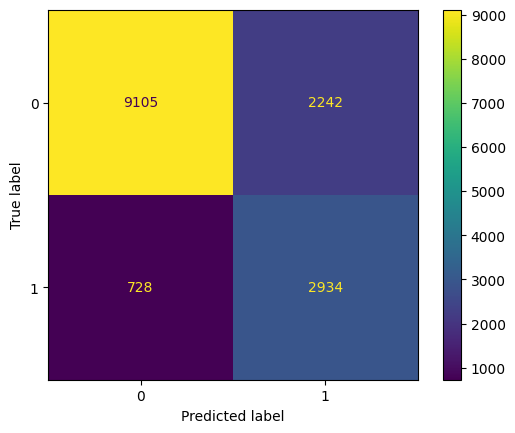

0.8728806618985224

In [62]:
import re

def extract_epoch(name):
    return int(re.findall(r"\d+", name)[0])

def evaluate_all_ckpts(ckpt_root, verbose=0):
    ckpt_files = sorted([
        f for f in os.listdir(ckpt_root)
        if f.endswith(".pt")
    ])

    ckpt_files = sorted(
    [f for f in os.listdir(ckpt_root) if f.endswith(".pt")],
    key=extract_epoch
    )

    best_auc = 0.0
    best_ckpt = None
    results = {}

    for ckpt_name in ckpt_files:
        ckpt_path = os.path.join(ckpt_root, ckpt_name)
        print(f"\nEvaluating {ckpt_name} ...")

        auc = evaluate(ckpt_path, verbose)
        results[ckpt_name] = auc

        print(f"AUC = {auc:.4f}")

        if auc > best_auc:
            best_auc = auc
            best_ckpt = ckpt_name

    print("\n==============================")
    print("BEST CHECKPOINT")
    print("Name :", best_ckpt)
    print("AUC  :", best_auc)
    print("==============================")

    return best_ckpt, best_auc, results

ckpt_root="./DualMemAE_Avenue/"

best_ckpt,_,_ = evaluate_all_ckpts(ckpt_root)

best_ckpt_path = os.path.join(ckpt_root, best_ckpt)

evaluate(best_ckpt_path, verbose=1)